# Effect Size Analysis:

Loads the benchmark CSV files and computes **Cliff's delta** effect sizes between various groups of algorithms


In [13]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from enum import Enum

sns.set_theme(style="whitegrid")

In [14]:
df = pd.read_csv("../../complex_env_dual_arm_collision_2026-09-17_00-32-28.csv")
df.set_index("file", inplace=True)

from algo_metadata import AlgoData, algo_metadata


In [15]:
EXCLUDED_ALGORITHMS = [
    "openGJK distance linear support",
    "libccd intersection linear support",
    "FCL intersection linear support",
    "FCL distance linear support",
]

included_algorithms = [a for a in df.columns if a not in EXCLUDED_ALGORITHMS]

In [16]:
df_long = df[included_algorithms].melt(var_name="Algorithm", value_name="Value")

df_long["Language"] = df_long["Algorithm"].map(lambda name: algo_metadata[name].language.value)
df_long["Category"] = df_long["Algorithm"].map(lambda name: algo_metadata[name].category)
df_long["Label"] = df_long["Algorithm"].map(lambda name: algo_metadata[name].pretty_name_full)

languages = [lang.value for lang in AlgoData.Language]
categories = list(AlgoData.Category)

df_long.head()

,Algorithm,Value,Language,Category,Label
0,libccd intersection,0.551189,C++,Category.INTERSECTION,libccd [bool]
1,libccd intersection,0.158834,C++,Category.INTERSECTION,libccd [bool]
2,libccd intersection,0.512233,C++,Category.INTERSECTION,libccd [bool]
3,libccd intersection,0.718223,C++,Category.INTERSECTION,libccd [bool]
4,libccd intersection,0.903157,C++,Category.INTERSECTION,libccd [bool]


## Effect size functions

**Cliff's delta** is used instead of Cohen's $d$ because collision-check runtimes are typically right-skewed / heavy-tailed, violating the normality assumption behind parametric effect sizes. Cliff's delta is distribution-free, robust to outliers, and standard in empirical algorithm-benchmarking studies (Vargha & Delaney, 2000).

$\delta \in [-1, 1]$: $\delta > 0$ means the first algorithm tends to be *slower*; $\delta < 0$ means it tends to be *faster*. Magnitude thresholds (Romano et al., 2006): $|\delta|<0.147$ negligible, $<0.33$ small, $<0.474$ medium, otherwise large.

In [17]:
def cliffs_delta(x, y):
    """Compute Cliff's delta effect size between two independent samples.

    delta > 0  -> x tends to be larger than y
    delta < 0  -> x tends to be smaller than y
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n1, n2 = len(x), len(y)
    u_stat, _ = stats.mannwhitneyu(x, y, alternative="less")
    # return cliffs delta:
    # return 2 * u_stat / (n1 * n2) - 1

    # alternatively, return probability that a random value from x is larger than a random value from y
    return u_stat / (n1 * n2)


def cliffs_delta_magnitude(delta):
    d = abs(delta)
    if d < 0.147:
        return "negligible"
    elif d < 0.33:
        return "small"
    elif d < 0.474:
        return "medium"
    else:
        return "large"


def pairwise_cliffs_delta_matrix(sub_df, group_col="Label", value_col="Value"):
    """Pairwise Cliff's delta matrix for all groups in sub_df, ordered by median value."""
    order = sub_df.groupby(group_col)[value_col].median().sort_values().index.tolist()
    groups = {}
    for algo in order:
        # group measurement values per algorithm and remove any NaN values:
        values_for_algo = sub_df.loc[sub_df[group_col] == algo, value_col].values
        groups[algo] = values_for_algo[~np.isnan(values_for_algo)]

    mat = pd.DataFrame(index=order, columns=order, dtype=float)
    for a in order:
        for b in order:
            mat.loc[a, b] = cliffs_delta(groups[a], groups[b]) if a != b else 0.0

    return mat


def cliffs_delta_matrix_to_latex(mat, caption, label, escape_underscores=True, lower_triangle_only=True):
    def esc(s):
        return s.replace("_", "\\_") if escape_underscores else s

    cols = [esc(c) for c in mat.columns]
    idx = [esc(i) for i in mat.index]
    n = len(mat)

    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append(f"\\begin{{tabular}}{{l{'c' * n}}}")
    lines.append("\\toprule")
    lines.append(" & " + " & ".join(cols) + " \\\\")
    lines.append("\\midrule")
    for i, (row_label, (_, row)) in enumerate(zip(idx, mat.iterrows())):
        vals = []
        for j, v in enumerate(row):
            if lower_triangle_only and j >= i:
                vals.append("")
            else:
                vals.append(f"{v:.2f}")
        lines.append(f"{row_label} & " + " & ".join(vals) + " \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    return "\n".join(lines)


def slugify(text):
    return text.lower().replace("++", "pp").replace(" ", "-")

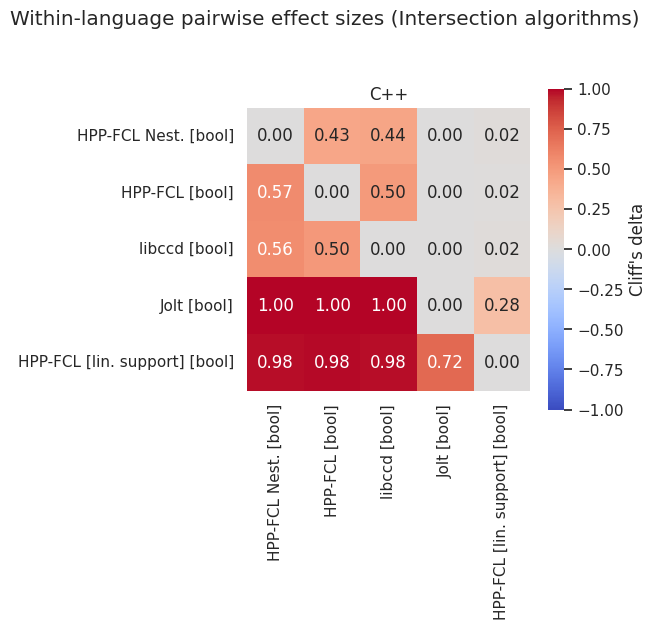

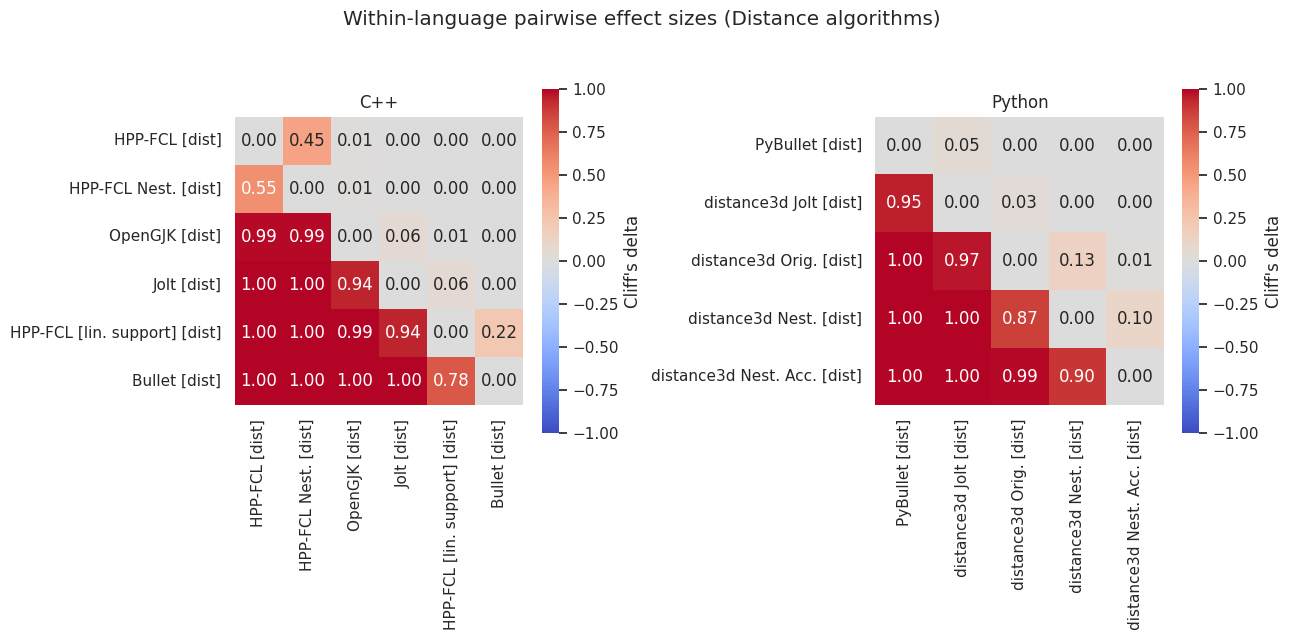

In [18]:
within_language_matrices = {}  # {category: {language: matrix}}

for category in categories:
    df_cat = df_long[df_long["Category"] == category]
    active_languages = [
        lang for lang in languages
        if df_cat.loc[df_cat["Language"] == lang, "Algorithm"].nunique() >= 2
    ]
    if not active_languages:
        continue

    fig, axes = plt.subplots(1, len(active_languages), figsize=(6.5 * len(active_languages), 6))
    if len(active_languages) == 1:
        axes = [axes]

    within_language_matrices[category] = {}

    for ax, lang in zip(axes, active_languages):
        sub = df_cat[df_cat["Language"] == lang]
        mat = pairwise_cliffs_delta_matrix(sub)
        within_language_matrices[category][lang] = mat

        sns.heatmap(
            mat.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
            # mask=np.triu(np.ones_like(mat, dtype=bool)),
            vmin=-1, vmax=1, center=0, ax=ax, square=True,
            cbar_kws={"label": "Cliff's delta"}
        )
        ax.set_title(f"{lang}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=90)
        ax.tick_params(axis="y", rotation=0)

    fig.suptitle(f"Within-language pairwise effect sizes ({category.value} algorithms)", y=1.03)
    plt.tight_layout()
    plt.savefig(f"effect_sizes_within_language_{slugify(category.value)}.pdf", bbox_inches="tight")
    plt.show()

In [19]:
for category, lang_matrices in within_language_matrices.items():
    for lang, mat in lang_matrices.items():
        print(cliffs_delta_matrix_to_latex(
            mat,
            caption=f"Pairwise Cliff's delta effect sizes between {lang} {category.value.lower()} algorithms.",
            label=f"tab:effect-size-{slugify(lang)}-{slugify(category.value)}"
        ))
        print()

\begin{table}[htbp]
\centering
\begin{tabular}{lccccc}
\toprule
 & HPP-FCL Nest. [bool] & HPP-FCL [bool] & libccd [bool] & Jolt [bool] & HPP-FCL [lin. support] [bool] \\
\midrule
HPP-FCL Nest. [bool] &  &  &  &  &  \\
HPP-FCL [bool] & 0.57 &  &  &  &  \\
libccd [bool] & 0.56 & 0.50 &  &  &  \\
Jolt [bool] & 1.00 & 1.00 & 1.00 &  &  \\
HPP-FCL [lin. support] [bool] & 0.98 & 0.98 & 0.98 & 0.72 &  \\
\bottomrule
\end{tabular}
\caption{Pairwise Cliff's delta effect sizes between C++ intersection algorithms.}
\label{tab:effect-size-cpp-intersection}
\end{table}

\begin{table}[htbp]
\centering
\begin{tabular}{lcccccc}
\toprule
 & HPP-FCL [dist] & HPP-FCL Nest. [dist] & OpenGJK [dist] & Jolt [dist] & HPP-FCL [lin. support] [dist] & Bullet [dist] \\
\midrule
HPP-FCL [dist] &  &  &  &  &  &  \\
HPP-FCL Nest. [dist] & 0.55 &  &  &  &  &  \\
OpenGJK [dist] & 0.99 & 0.99 &  &  &  &  \\
Jolt [dist] & 1.00 & 1.00 & 0.94 &  &  &  \\
HPP-FCL [lin. support] [dist] & 1.00 & 1.00 & 0.99 & 0.94 &  &  \\
B

Fastest Intersection algorithm per language (by median runtime):


,Language,Algorithm,Median [µs]
0,C++,FCL intersection,0.643635
5,Python,distance3d Jolt (intersection),46.857160


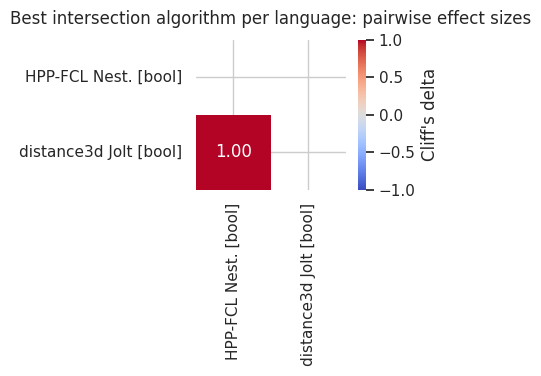

Fastest Distance algorithm per language (by median runtime):


,Language,Algorithm,Median [µs]
2,C++,FCL distance defaultGJK,1.249414
6,Python,Pybullet,35.511865


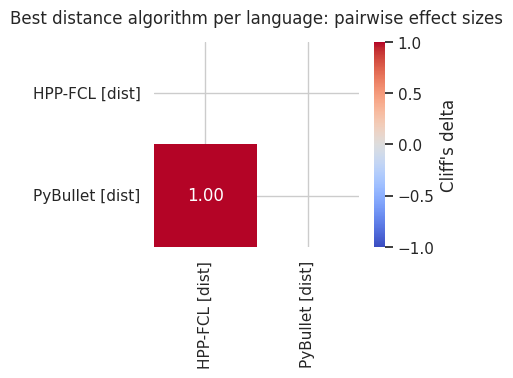

In [20]:
best_matrices = {}
best_samples = {}    # reused later for CI generation

for category in categories:
    df_cat = df_long[df_long["Category"] == category]
    if df_cat.empty:
        continue

    median_per_algo = (
        df_cat.groupby(["Language", "Algorithm"])["Value"]
        .median()
        .reset_index()
    )
    best_idx = median_per_algo.groupby("Language")["Value"].idxmin()
    best_per_language = median_per_algo.loc[best_idx].sort_values("Value")

    print(f"Fastest {category.value} algorithm per language (by median runtime):")
    display(best_per_language.rename(columns={"Value": "Median [µs]"}))

    if len(best_per_language) < 2:
        print(f"Only one language has {category.value.lower()} algorithms remaining - skipping comparison.\n")
        continue

    best_algorithms = best_per_language["Algorithm"].tolist()
    best_df = df_cat[df_cat["Algorithm"].isin(best_algorithms)]
    best_mat = pairwise_cliffs_delta_matrix(best_df)
    best_matrices[category] = best_mat
    best_samples[category] = {
        algo_metadata[a].pretty_name_full: best_df.loc[best_df["Algorithm"] == a, "Value"].values
        for a in best_algorithms
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        best_mat.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
        mask=np.triu(np.ones_like(best_mat, dtype=bool)),
        vmin=-1, vmax=1, center=0, ax=ax, square=True,
        cbar_kws={"label": "Cliff's delta"}
    )
    ax.set_title(f"Best {category.value.lower()} algorithm per language: pairwise effect sizes", y=1.05)
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.savefig(f"effect_sizes_best_per_language_{slugify(category.value)}.pdf", bbox_inches="tight")
    plt.show()

In [21]:
for category, best_mat in best_matrices.items():
    print(f"--- {category.value} ---")
    print(cliffs_delta_matrix_to_latex(
        best_mat,
        caption=f"Cliff's delta effect sizes between the fastest {category.value.lower()} algorithm of each language.",
        label=f"tab:effect-size-best-per-language-{slugify(category.value)}"
    ))

    labels = best_mat.index.tolist()
    print()
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            d = best_mat.iloc[i, j]
            mag = cliffs_delta_magnitude(d)
            faster = labels[i] if d < 0 else labels[j]
            print(f"{labels[i]} vs. {labels[j]}: delta={d:.2f} ({mag}); {faster} tends to be faster.")
    print()

--- Intersection ---
\begin{table}[htbp]
\centering
\begin{tabular}{lcc}
\toprule
 & HPP-FCL Nest. [bool] & distance3d Jolt [bool] \\
\midrule
HPP-FCL Nest. [bool] &  &  \\
distance3d Jolt [bool] & 1.00 &  \\
\bottomrule
\end{tabular}
\caption{Cliff's delta effect sizes between the fastest intersection algorithm of each language.}
\label{tab:effect-size-best-per-language-intersection}
\end{table}

HPP-FCL Nest. [bool] vs. distance3d Jolt [bool]: delta=0.00 (negligible); distance3d Jolt [bool] tends to be faster.

--- Distance ---
\begin{table}[htbp]
\centering
\begin{tabular}{lcc}
\toprule
 & HPP-FCL [dist] & PyBullet [dist] \\
\midrule
HPP-FCL [dist] &  &  \\
PyBullet [dist] & 1.00 &  \\
\bottomrule
\end{tabular}
\caption{Cliff's delta effect sizes between the fastest distance algorithm of each language.}
\label{tab:effect-size-best-per-language-distance}
\end{table}

HPP-FCL [dist] vs. PyBullet [dist]: delta=0.00 (negligible); PyBullet [dist] tends to be faster.



## Confidence Intervals for best-per-language algorithms:

In [22]:
def cliffs_delta_ci(x, y, n_boot=2000, ci=0.95, seed=42):
    """Percentile bootstrap confidence interval for Cliff's delta.

    Returns (point_estimate, lower, upper).
    """
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    rng = np.random.default_rng(seed)

    point = cliffs_delta(x, y)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        bx = x[rng.integers(0, nx, nx)]
        by = y[rng.integers(0, ny, ny)]
        boot[b] = cliffs_delta(bx, by)

    alpha = 1 - ci
    lower, upper = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, lower, upper


def ci_matrix_to_latex(rows, caption, label, escape_underscores=True):
    """Render a list of (comparison, delta, lower, upper, magnitude) tuples as a LaTeX table."""
    def esc(s):
        return s.replace("_", "\\_") if escape_underscores else s

    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append("\\begin{tabular}{lccc}")
    lines.append("\\toprule")
    lines.append("Comparison & $\\delta$ & 95\\% CI & Magnitude \\\\")
    lines.append("\\midrule")
    for comparison, delta, lower, upper, magnitude in rows:
        lines.append(f"{esc(comparison)} & {delta:.2f} & [{lower:.2f}, {upper:.2f}] & {magnitude} \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    return "\n".join(lines)

--- Intersection: 95% CI for Cliff's delta (best algorithm per language) ---


,Comparison,δ,CI lower,CI upper,Magnitude
0,HPP-FCL Nest. [bool] vs. distance3d Jolt [bool],0.0,0.0,0.0,negligible


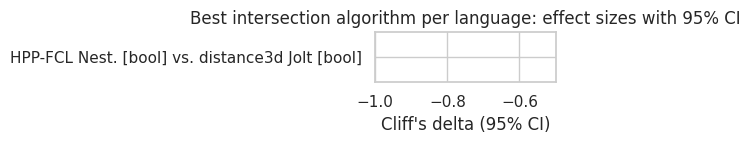

--- Distance: 95% CI for Cliff's delta (best algorithm per language) ---


,Comparison,δ,CI lower,CI upper,Magnitude
0,HPP-FCL [dist] vs. PyBullet [dist],0.0,0.0,0.0,negligible


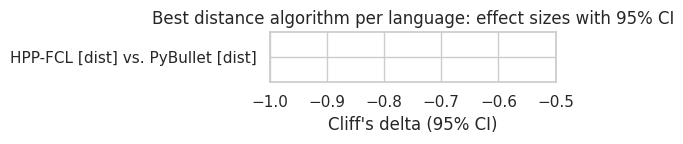

In [23]:
ci_results = {}  # {category: DataFrame}

for category, samples in best_samples.items():
    algo_order = best_matrices[category].index.tolist()  # already sorted by median (fastest first)

    rows = []
    for i in range(len(algo_order)):
        for j in range(i + 1, len(algo_order)):
            a, b = algo_order[i], algo_order[j]
            delta, lower, upper = cliffs_delta_ci(samples[a], samples[b])
            rows.append({
                "Comparison": f"{a} vs. {b}",
                "delta": delta,
                "ci_lower": lower,
                "ci_upper": upper,
                "magnitude": cliffs_delta_magnitude(delta),
            })

    ci_df = pd.DataFrame(rows)
    ci_results[category] = ci_df

    print(f"--- {category.value}: 95% CI for Cliff's delta (best algorithm per language) ---")
    display(ci_df.rename(columns={
        "delta": "δ", "ci_lower": "CI lower", "ci_upper": "CI upper", "magnitude": "Magnitude"
    }))

    # Forest plot: point estimate + CI whiskers per comparison
    fig, ax = plt.subplots(figsize=(6, 0.6 * len(ci_df) + 1))
    y_pos = np.arange(len(ci_df))
    errors = np.abs(ci_df[["ci_lower", "ci_upper"]].values.T - ci_df["delta"].values)
    ax.errorbar(ci_df["delta"], y_pos, xerr=errors, fmt="o", color="C0", capsize=4)
    ax.axvline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ci_df["Comparison"])
    ax.set_xlim(-1, -0.5)
    ax.set_xlabel("Cliff's delta (95% CI)")
    ax.set_title(f"Best {category.value.lower()} algorithm per language: effect sizes with 95% CI")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"effect_sizes_best_per_language_ci_{slugify(category.value)}.pdf", bbox_inches="tight")
    plt.show()

In [24]:
for category, ci_df in ci_results.items():
    rows = [
        (r.Comparison, r.delta, r.ci_lower, r.ci_upper, r.magnitude)
        for r in ci_df.itertuples()
    ]
    print(f"--- {category.value} ---")
    print(ci_matrix_to_latex(
        rows,
        caption=f"Cliff's delta effect sizes (95% bootstrap CI) between the fastest {category.value.lower()} algorithm of each language.",
        label=f"tab:effect-size-ci-best-per-language-{slugify(category.value)}"
    ))
    print()

--- Intersection ---
\begin{table}[htbp]
\centering
\begin{tabular}{lccc}
\toprule
Comparison & $\delta$ & 95\% CI & Magnitude \\
\midrule
HPP-FCL Nest. [bool] vs. distance3d Jolt [bool] & 0.00 & [0.00, 0.00] & negligible \\
\bottomrule
\end{tabular}
\caption{Cliff's delta effect sizes (95% bootstrap CI) between the fastest intersection algorithm of each language.}
\label{tab:effect-size-ci-best-per-language-intersection}
\end{table}

--- Distance ---
\begin{table}[htbp]
\centering
\begin{tabular}{lccc}
\toprule
Comparison & $\delta$ & 95\% CI & Magnitude \\
\midrule
HPP-FCL [dist] vs. PyBullet [dist] & 0.00 & [0.00, 0.00] & negligible \\
\bottomrule
\end{tabular}
\caption{Cliff's delta effect sizes (95% bootstrap CI) between the fastest distance algorithm of each language.}
\label{tab:effect-size-ci-best-per-language-distance}
\end{table}

